# GloFASv5 Calibration Results - Basic Analysis

This notebook provides basic analysis of the GloFASv5 calibration results.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Load the data
# df = pd.read_csv('GloFASv5_Calibration_Results_updated.csv')
df = pd.read_csv('GloFASv5_stations_metadata_calfunction_KGE_JSD_20March2026_final.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")

Dataset shape: (5379, 22)

Column names:
['ID', 'name', 'basin', 'river', 'provider', 'iso', 'DrainageArea_prov', 'DrainageArea_LDD', 'lat', 'long', 'LISFLOOD_X', 'LISFLOOD_Y', 'SourceGlo', 'GlofasV5', 'Obs_start', 'Obs_end', 'Split_date_CALstart', 'KGEmod', 'JSD', 'Function', 'Region', 'Basin']


## 1. Overview of the Dataset

In [13]:
df[df["name"]=="Jenbach-Rotholz"]

,ID,name,basin,river,provider,iso,DrainageArea_prov,DrainageArea_LDD,lat,long,LISFLOOD_X,LISFLOOD_Y,SourceGlo,GlofasV5,Obs_start,Obs_end,Split_date_CALstart,Kling Gupta Efficiency (KGE'),JSD,Function,Region,Basin
85,180,Jenbach-Rotholz,Danube,Inn,1013,AT,7230.7,7210.88,47.388857,11.789238,11.775,47.375,NRT,calibrated,31/10/2008 00:00',01/01/2024 00:00',31/10/2008 00:00',0.928211,0.025833,KGEJSD,Europe,Danube


In [17]:
# Basic info
print("First few rows:")
df.head()

First few rows:


,ID,name,basin,river,provider,iso,DrainageArea_prov,DrainageArea_LDD,lat,long,LISFLOOD_X,LISFLOOD_Y,SourceGlo,GlofasV5,Obs_start,Obs_end,Split_date_CALstart,KGEmod,JSD,Function,Region,Basin
0,4,Barby,Elbe,Elbe,1004,DE,94060.00,93699.47,51.984836,11.882244,11.875,52.025,NRT,calibrated,01/01/1980 00:00',01/01/2000 00:00',01/01/1980 00:00',0.843939,0.030255,KGEJSD,Europe,ElbeOderEmsWeser
1,5,Wittenberg / Lutherstadt,Elbe,Elbe,1004,DE,61879.00,60938.53,51.856531,12.646309,12.625,51.875,NRT,calibrated,01/01/1980 00:00',01/01/2011 00:00',01/01/1991 00:00',0.834721,0.009026,KGEJSD,Europe,ElbeOderEmsWeser
2,6,Malliss OP,Elbe,Muritz-Elde,1004,DE,2879.00,3161.95,53.190627,11.345254,11.425,53.175,NRT,calibrated,01/01/1980 00:00',31/12/2010 00:00',31/12/1990 00:00',0.867403,0.080963,KGEJSD,Europe,ElbeOderEmsWeser
3,9,Rathenow UP,Elbe,Lower Havel,1004,DE,19288.46,18271.30,52.607446,12.321014,12.325,52.625,efas,calibrated,01/01/1990 00:00',19/05/2010 00:00',17/05/1990 00:00',0.787487,0.073550,KGEJSD,Europe,ElbeOderEmsWeser
4,11,Calbe Grizehne,Elbe,Saale,1004,DE,23719.00,23560.46,51.916414,11.812211,11.825,51.925,HIST,calibrated,01/01/1980 00:00',31/12/2019 00:00',03/05/1997 00:00',0.849686,0.039989,KGEJSD,Europe,ElbeOderEmsWeser


In [5]:
# Data types
print("Data types:")
df.dtypes

Data types:


efas                      float64
name                       object
basin                      object
river                      object
provider                  float64
iso                        object
DrainageArea_prov         float64
DrainageArea_LDD          float64
lat_x                     float64
long                      float64
LISFLOOD_X                float64
LISFLOOD_Y                float64
GlofasID                   object
note                       object
oldnotes                   object
SourceGlo                  object
GlofasV5                   object
ID                        float64
lat_y                     float64
lon                       float64
v4calib                    object
v4calib_ID                 object
modKGE_v5                 float64
corr_v5                   float64
var_v5                    float64
bias_v5                   float64
NSE_v5                    float64
modKGE_v4                 float64
corr_v4                   float64
var_v4        

In [6]:
# Missing values in key columns
key_cols = ['modKGE_v5', 'NSE_v5', 'corr_v5', 'var_v5', 'bias_v5', 'basin', 'river', 'iso', 'Region']
print("Missing values in key columns:")
for col in key_cols:
    if col in df.columns:
        missing = df[col].isna().sum()
        print(f"  {col}: {missing} ({missing/len(df)*100:.1f}%)")

Missing values in key columns:
  modKGE_v5: 15463 (74.9%)
  NSE_v5: 15463 (74.9%)
  corr_v5: 15463 (74.9%)
  var_v5: 15463 (74.9%)
  bias_v5: 15463 (74.9%)
  basin: 6 (0.0%)
  river: 46 (0.2%)
  iso: 56 (0.3%)
  Region: 15460 (74.9%)


## 2. Global Statistics for Key Metrics

In [7]:
# Convert metrics to numeric
metrics = ['modKGE_v5', 'NSE_v5', 'corr_v5', 'var_v5', 'bias_v5']
for col in metrics:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Filter calibrated stations
df_calib = df[df['modKGE_v5'].notna()].copy()
print(f"Total calibrated stations: {len(df_calib)}")

# Statistics for each metric
print("\nGlobal statistics for calibrated stations:")
df_calib[metrics].describe()

Total calibrated stations: 5180

Global statistics for calibrated stations:


,modKGE_v5,NSE_v5,corr_v5,var_v5,bias_v5
count,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000
mean,0.668884,0.340865,0.719924,0.965282,1.003645
std,0.208433,1.071413,0.159794,0.134997,0.171644
min,-2.308284,-48.754459,-0.201050,0.183541,-0.004868
25%,0.593484,0.277360,0.646786,0.908104,0.945446
50%,0.714265,0.501110,0.751596,0.961007,0.991142
75%,0.800621,0.659472,0.832505,1.008568,1.039412
max,0.966373,0.943038,0.973508,2.604624,4.273292


## 3. Analysis by Country

In [8]:
# Count stations per country
country_stats = df_calib.groupby('iso').agg({
    'name': 'count',
    'modKGE_v5': 'mean',
    'NSE_v5': 'mean'
}).rename(columns={'name': 'n_stations'})

country_stats = country_stats.sort_values('n_stations', ascending=False)
print("Stations per country (top 20):")
country_stats.head(20)

Stations per country (top 20):


,n_stations,modKGE_v5,NSE_v5
iso,,,
BR,1086,0.666765,0.217447
US,729,0.667681,0.349467
CA,460,0.745284,0.517057
ZA,190,0.439625,-0.037262
IN,173,0.517129,0.228857
FR,162,0.791176,0.636091
ES,133,0.653454,0.326540
DE,122,0.816367,0.656202
KZ,116,0.645046,0.285304


## 4. Analysis by Basin

In [9]:
# Count stations per basin
basin_stats = df_calib.groupby('basin').agg({
    'name': 'count',
    'modKGE_v5': ['mean', 'median'],
    'NSE_v5': ['mean', 'median']
}).round(4)
basin_stats.columns = ['n_stations', 'modKGE_mean', 'modKGE_median', 'NSE_mean', 'NSE_median']
basin_stats = basin_stats.sort_values('n_stations', ascending=False)
print("Stations per basin (top 15):")
basin_stats.head(15)

Stations per basin (top 15):


,n_stations,modKGE_mean,modKGE_median,NSE_mean,NSE_median
basin,,,,,
Danube,238,0.7636,0.7787,0.5773,0.6040
Mississippi,138,0.6393,0.6988,0.2772,0.4782
Mackenzie,71,0.7939,0.8192,0.5070,0.7093
Coastal,71,0.5207,0.5892,0.1876,0.3549
Rhine,67,0.8413,0.8372,0.7139,0.7053
RIOS PARANÁ.PARANAPANEMA E ...,67,0.6240,0.6282,0.2401,0.2900
Vistula,64,0.7698,0.7681,0.5806,0.5692
RIO AMAZONAS.MADEIRA.GUAPORÉ....,57,0.8295,0.8399,0.7126,0.7476
Elbe,56,0.7592,0.7674,0.5586,0.5820


## 5. Analysis by Region

In [10]:
# Count stations per region
region_stats = df_calib.groupby('Region').agg({
    'name': 'count',
    'modKGE_v5': 'mean',
    'NSE_v5': 'mean'
}).rename(columns={'name': 'n_stations'}).round(4)

region_stats = region_stats.sort_values('n_stations', ascending=False)
print("Stations per region:")
region_stats

Stations per region:


,n_stations,modKGE_v5,NSE_v5
Region,,,
SouthAmerica_LaPlata,357,0.6454,0.2284
NorthAmerica_Mississipi,317,0.6132,0.2466
Europe_Danube,260,0.7605,0.5681
SouthAmerica_Amazonas,247,0.7892,0.6317
SouthAmerica_SouthBrazilUruguayAtlanticCoast,205,0.6150,0.1714
...,...,...,...
Asia_Volga,11,0.7358,0.4597
Africa_SouthAfrica_WestCoast,8,0.5501,0.2746
Europe_Dniester,8,0.7372,0.5262


## 6. Distribution Plots

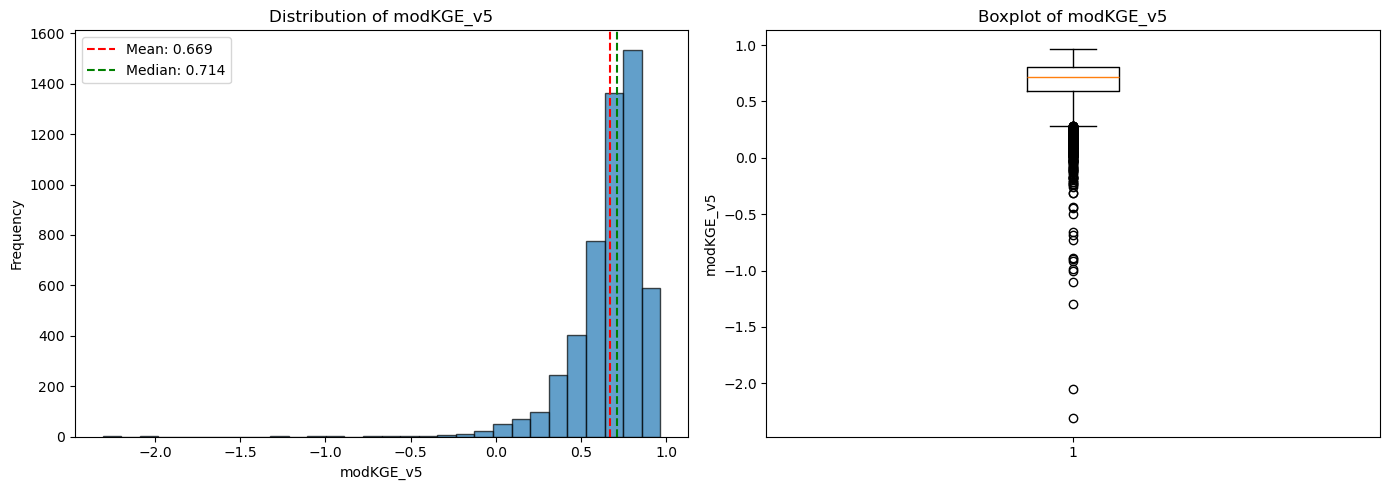

In [11]:
# Distribution of modKGE_v5
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_calib['modKGE_v5'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(df_calib['modKGE_v5'].mean(), color='red', linestyle='--', label=f'Mean: {df_calib["modKGE_v5"].mean():.3f}')
axes[0].axvline(df_calib['modKGE_v5'].median(), color='green', linestyle='--', label=f'Median: {df_calib["modKGE_v5"].median():.3f}')
axes[0].set_xlabel('modKGE_v5')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of modKGE_v5')
axes[0].legend()

# Boxplot
axes[1].boxplot(df_calib['modKGE_v5'].dropna(), vert=True)
axes[1].set_ylabel('modKGE_v5')
axes[1].set_title('Boxplot of modKGE_v5')

plt.tight_layout()
plt.show()

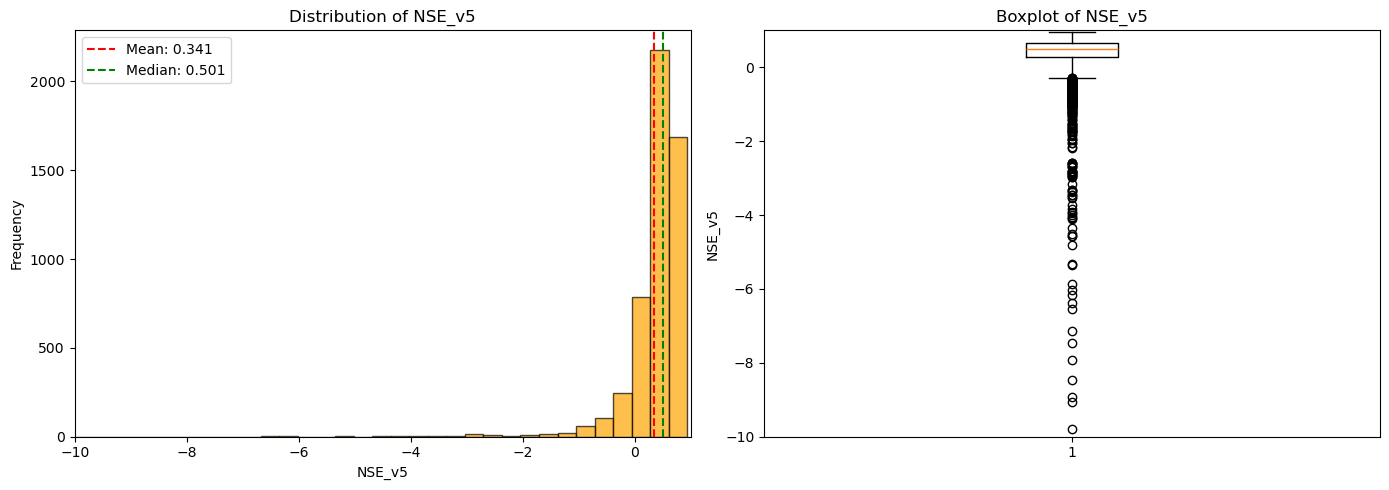

In [31]:
# Distribution of NSE_v5
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_calib['NSE_v5'].dropna(), bins=150, edgecolor='black', alpha=0.7, color='orange')
axes[0].axvline(df_calib['NSE_v5'].mean(), color='red', linestyle='--', label=f'Mean: {df_calib["NSE_v5"].mean():.3f}')
axes[0].axvline(df_calib['NSE_v5'].median(), color='green', linestyle='--', label=f'Median: {df_calib["NSE_v5"].median():.3f}')
axes[0].set_xlabel('NSE_v5')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of NSE_v5')
axes[0].legend()
axes[0].set_xlim(-10,1)

# Boxplot
axes[1].boxplot(df_calib['NSE_v5'].dropna(), vert=True)
axes[1].set_ylabel('NSE_v5')
axes[1].set_title('Boxplot of NSE_v5')
axes[1].set_ylim(-10,1)

plt.tight_layout()
plt.show()

## 7. Comparison: GloFASv4 vs GloFASv5

In [13]:
# Convert v4 metrics to numeric
df_calib['modKGE_v4'] = pd.to_numeric(df_calib['modKGE_v4'], errors='coerce')
df_calib['NSE_v4'] = pd.to_numeric(df_calib['NSE_v4'], errors='coerce')

# Compare v4 and v5
df_both = df_calib[(df_calib['modKGE_v4'].notna()) & (df_calib['modKGE_v5'].notna())].copy()
print(f"Stations with both v4 and v5 metrics: {len(df_both)}")

print("\nComparison of v4 vs v5:")
comparison = pd.DataFrame({
    'modKGE_v4': df_both['modKGE_v4'].describe(),
    'modKGE_v5': df_both['modKGE_v5'].describe(),
    'NSE_v4': df_both['NSE_v4'].describe(),
    'NSE_v5': df_both['NSE_v5'].describe()
})
comparison

Stations with both v4 and v5 metrics: 5180

Comparison of v4 vs v5:


,modKGE_v4,modKGE_v5,NSE_v4,NSE_v5
count,5180.000000,5180.000000,5180.000000,5180.000000
mean,0.123147,0.668884,-2.508865,0.340865
std,5.456652,0.208433,68.455102,1.071413
min,-377.897028,-2.308284,-4792.647215,-48.754459
25%,0.166297,0.593484,-0.161462,0.277360
50%,0.498211,0.714265,0.312255,0.501110
75%,0.699125,0.800621,0.564171,0.659472
max,2.643902,0.966373,0.940906,0.943038


In [14]:
# Improvement from v4 to v5
df_both['diff_modKGE'] = df_both['modKGE_v5'] - df_both['modKGE_v4']
df_both['diff_NSE'] = df_both['NSE_v5'] - df_both['NSE_v4']

print("Improvement from v4 to v5:")
print(f"  modKGE improvement: mean = {df_both['diff_modKGE'].mean():.4f}, median = {df_both['diff_modKGE'].median():.4f}")
print(f"  NSE improvement: mean = {df_both['diff_NSE'].mean():.4f}, median = {df_both['diff_NSE'].median():.4f}")
print(f"\n  Stations with improved modKGE: {(df_both['diff_modKGE'] > 0).sum()} ({(df_both['diff_modKGE'] > 0).sum()/len(df_both)*100:.1f}%)")
print(f"  Stations with improved NSE: {(df_both['diff_NSE'] > 0).sum()} ({(df_both['diff_NSE'] > 0).sum()/len(df_both)*100:.1f}%)")

Improvement from v4 to v5:
  modKGE improvement: mean = 0.5457, median = 0.1711
  NSE improvement: mean = 2.8497, median = 0.1195

  Stations with improved modKGE: 4450 (85.9%)
  Stations with improved NSE: 3977 (76.8%)


## 8. Top and Bottom Performing Stations

In [45]:
# Top 10 stations by modKGE_v5
print("Top 10 stations by modKGE_v5:")
df_calib.nlargest(10, 'modKGE_v5')[['name', 'basin', 'river', 'iso', 'modKGE_v5', 'NSE_v5']]

Top 10 stations by modKGE_v5:


,name,basin,river,iso,modKGE_v5,NSE_v5
12249,UHE SÃO MANOEL JUSANTE 1,RIO AMAZONAS.TAPAJÓS.JURUENA..,TELES PIRES (OU SÃO MANUEL),BR,0.966373,0.934094
4736,Nakhon Phanom,Mekong,Mekong,LA,0.965547,0.936175
12336,BUBURÉ,RIO AMAZONAS.TAPAJÓS.JURUENA..,Tapajós,BR,0.959391,0.921744
12325,FORTALEZA,RIO AMAZONAS.TAPAJÓS.JURUENA..,Tapajós,BR,0.958932,0.924826
4730,Near Vientiane,Mekong,Mekong,LA,0.958211,0.918589
4731,Chiang Khan,Mekong,Mekong,TH,0.956364,0.914681
4191,Kamenna Obi,Ob,Ob,RU,0.955605,0.913745
4106,Kolpashevo,Ob,Ob,RU,0.953884,0.915865
4732,Nong Khai,Mekong,Mekong,TH,0.952195,0.910220
4015,Eagle Ak,Yukon,Yukon,US,0.950699,0.939799


In [16]:
# Bottom 10 stations by modKGE_v5
print("Bottom 10 stations by modKGE_v5:")
df_calib.nsmallest(10, 'modKGE_v5')[['name', 'basin', 'river', 'iso', 'modKGE_v5', 'NSE_v5']]

Bottom 10 stations by modKGE_v5:


,name,basin,river,iso,modKGE_v5,NSE_v5
2715,YEGUAS 5049,Guadalquivir,Yeguas o Pradillo,ES,-2.308284,-14.773990
4598,Near Canadian Tx,Mississippi,Canadian,US,-2.052429,-8.469202
11273,GAVIÃO II,RIOS PARAGUAÇÚ.JEQUIRICÁ E ...,JACUÍPE,BR,-1.300157,-6.387299
12806,SALIMWANI (55232108),Rufiji,Great Ruaha,TZ,-1.098409,-5.334612
5640,Potrero de las Tablas,Sali-Dulce,Lules,AR,-1.004184,-4.060827
6995,Timbavati River at Piet Grobler Dam Kruger Nat...,Olifants,Timbavati,ZA,-0.988999,-0.072123
14305,NEAR STAMFORD. NEBR.,Lower Sappa,SAPPA CREEK,US,-0.915699,-2.867453
5524,Malakal,Nile,White Nile,SS,-0.896577,-48.754459
4707,Palos Blancos,Coastal,Humaya,MX,-0.892924,0.433761
6887,Selons River at Moedwil,Limpopo,Selons,ZA,-0.731306,-4.577548


## 9. Correlation between Metrics

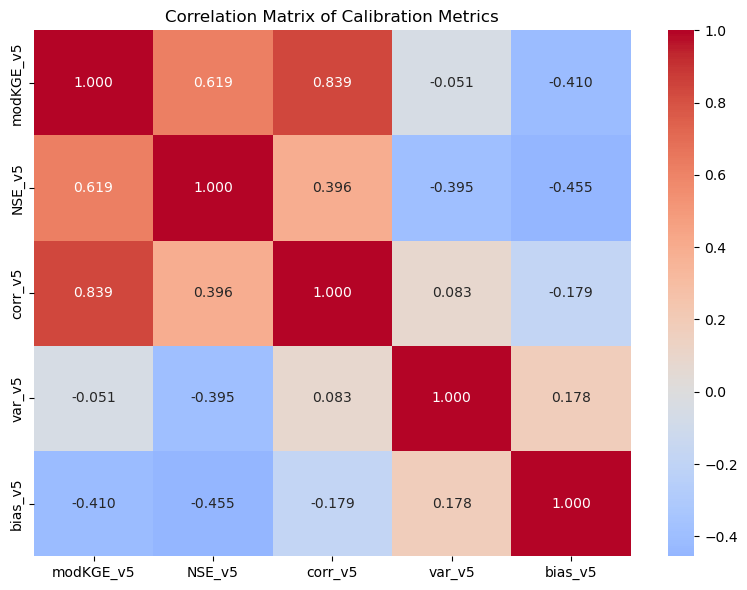

In [17]:
# Correlation matrix
corr_matrix = df_calib[metrics].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Correlation Matrix of Calibration Metrics')
plt.tight_layout()
plt.show()

## 10. Scatter Plot: modKGE vs NSE

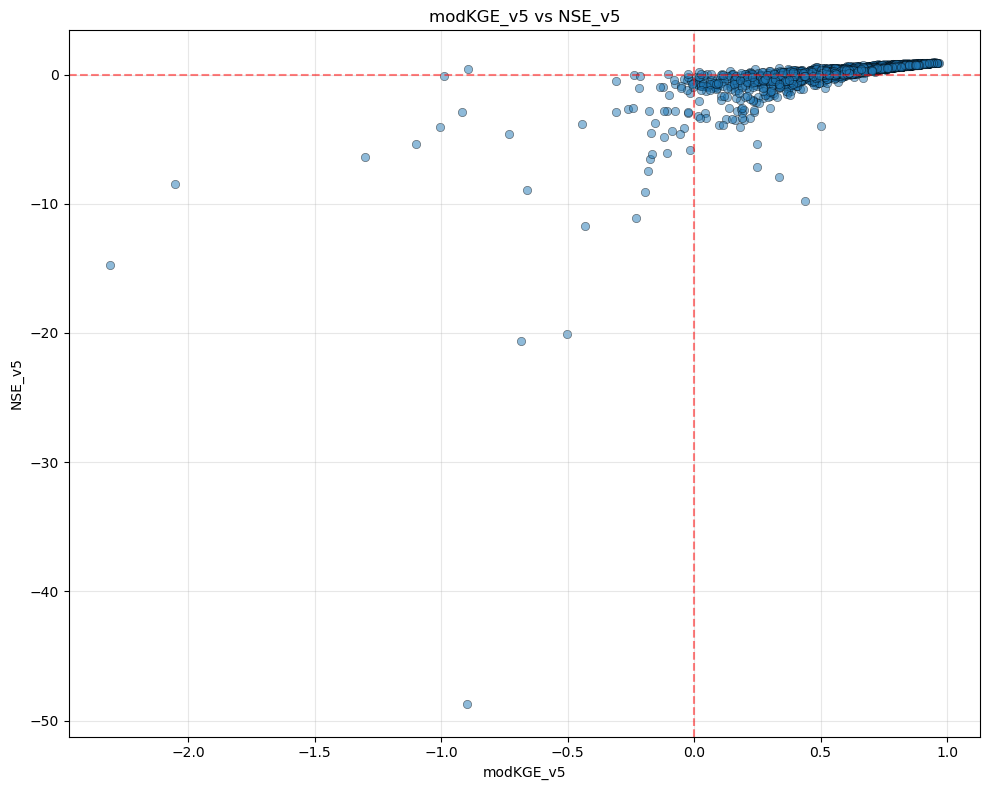

Correlation between modKGE_v5 and NSE_v5: 0.6188


In [18]:
plt.figure(figsize=(10, 8))
plt.scatter(df_calib['modKGE_v5'], df_calib['NSE_v5'], alpha=0.5, edgecolors='black', linewidth=0.5)
plt.xlabel('modKGE_v5')
plt.ylabel('NSE_v5')
plt.title('modKGE_v5 vs NSE_v5')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Correlation between modKGE_v5 and NSE_v5: {df_calib['modKGE_v5'].corr(df_calib['NSE_v5']):.4f}")